# Customer Churn

Il churn (abbandono del cliente) è uno dei problemi aziendali più critici: acquisire un nuovo cliente costa mediamente dalle 5 alle 25 volte di più che mantenerne uno esistente, risulta quindi molto comodo riuscire a prevedere se un cliente si allontanerà dall'azienda.

L'obiettivo di questo notebook è costruire un modello di classificazione binaria in grado di predire se un cliente abbandonerà o meno la compagnia con particolare focus sui clienti classificati "a rischio", ovvero quei clienti per cui il modello predice un abbandono imminente. Identificare questi clienti con anticipo peremtte all'azienda di attivare strategie attue alla fidelizzazione.

Il dataset utilizzato è *IBM Telco Customer Churn*, reperibile da Kaggle al seguente [link](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data).

## Librerie

In [181]:
import os
import requests
import zipfile
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

## Descrizione del dataset

Ogni riga rappresenta le informazioni su un cliente di una compagnia telefonica fittizia. Le feature sono:

- `customerID`: identificatore univoco del cliente

**Dati demografici**
- `gender`: sesso del cliente (Male/Female)
- `SeniorCitizen`: se il cliente è categorizzato come anziano (1/0)
- `Partner`: se il cliente ha un partner (Yes/No)
- `Dependents`: se il cliente ha persone a carico (Yes/No)

**Dati contrattuali e di utilizzo**
- `tenure`: numero di mesi come cliente
- `Contract`: tipo di contratto (Month-to-month, One year, Two year)
- `PaperlessBilling`: se usa la fatturazione elettronica (Yes/No)
- `PaymentMethod`: metodo di pagamento (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))

**Servizi sottoscritti**
- `PhoneService`: servizio telefonico (Yes/No)
- `MultipleLines`: linee multiple (Yes/No/No phone service)
- `InternetService`: tipo di connessione (DSL, Fiber optic, No)
- `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`: servizi aggiuntivi (Yes/No/No internet service)

**Dati economici**
- `MonthlyCharges`: spesa mensile in dollari
- `TotalCharges`: spesa totale storica in dollari

**Varibiabile dipendente**:
- `Churn`: se il cliente ha abbandonato la compagnia nel mese corrente (Yes/No)

## Caricamento e pulizia iniziale
Scarichiamo i dati ed importiamoli in un dataframe Pandas. Ne visualizziamo una parte per fare una prima ispezione sulla loro struttura.

In [182]:
csv_filename = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
url = "https://www.kaggle.com/api/v1/datasets/download/blastchar/telco-customer-churn"

# scarica ed estrae lo zip, se il suo contenuto non esiste già
if not os.path.exists(csv_filename):
    r = requests.get(url)
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        z.extractall()

churn_ds = pd.read_csv(csv_filename)
churn_ds.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [183]:
churn_ds.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


Possiamo vedere come il dataframe presenti 21 feature che descrivono 7043 istanze.

In [184]:
churn_ds.shape

(7043, 21)

Effettuamo ora una prima scrematura e manipolazione dei dati. Ispezionando i tipi delle feature ci si accorge che `TotalCharges` risulta di tipo `object`, invece che `float`.

In [185]:
churn_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Questo è dovuto dal fatto che alcune righe contengono spazi vuoti `" "` al posto di valori numerici. Il motivo è che i nuovi clienti (`tenure = 0`) non hanno ancora ricevuto una fattura, ne consegue che `TotalCharges` è vuoto. Verifichiamo:

In [186]:
churn_ds[churn_ds['TotalCharges'].str.strip() == ''][['tenure', 'MonthlyCharges', 'TotalCharges']]

,tenure,MonthlyCharges,TotalCharges
488,0,52.55,
753,0,20.25,
936,0,80.85,
1082,0,25.75,
1340,0,56.05,
3331,0,19.85,
3826,0,25.35,
4380,0,20.00,
5218,0,19.70,
6670,0,73.35,


Effettuiamo una correzione di `TotalCharges`, convertendo tutti gli spazi vuoti in `NaN` (che gestiamo subito dopo) e stampiamo quanti valori nulli sono stati generati:

In [187]:
# coerce converte gli spazi vuoti in NaN
churn_ds["TotalCharges"] = pd.to_numeric(churn_ds["TotalCharges"], errors="coerce")

print(churn_ds["TotalCharges"].isna().sum())

11


Poichè la quantità di clienti con `tenure = 0`, cioè appena entrati, è esigua (appena 11 istanze, lo 0.15% del dataset), si decide di rimuovere le righe interessante invece che rimpiazzare i valori nulli.

In [188]:
churn_ds = churn_ds.dropna()
churn_ds.shape

(7032, 21)

La colonna `customerID` non aggiunge alcun tipo di informazione utile, si decide quindi di rimuoverla e usare come identificatore l'indice del frame pandas.

In [189]:
churn_ds = churn_ds.drop(columns=['customerID'])
churn_ds.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Analisi esplorativa
Il dataset contiene molte più feature categoriche che numeriche. Esploriamole separatamente.

In [190]:
# variabili numeriche
churn_ds.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


E' possibile notare le seguenti caratteristiche:
- `tenure` indica che i clienti in media hanno circa 32 mesi di anzianità. Il 25° percentile è di 9 mesi, suggerendo quindi che una quota rilevante di clienti è relativamente recente. La deviazione standard è di 24 mesi, indicando una bassa omogeneità dei dati.
- `SeniorCitizen`: la media è 0.16, quindi solo il 16% dei clienti viene classificato come anziano.

In [191]:
# variabili categoriche
churn_ds.describe(include="object")

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,3549,3639,4933,6352,3385,3096,3497,3087,3094,3472,2809,2781,3875,4168,2365,5163


- la distribuzione di `gender` è molto ben bilanciata: Male occupa circa il 50% delle istanze
- la maggior parte dei clienti non ha partner ne persone a carico
- quasi tutti i clienti hanno il servizio telefonico (circa il 90%)
- il contratto più diffuso è Month-to-month. Essendo una stipulazione a rinnovo mensile, si ipotizza che possa essere associata a maggior rischio di churn.
- la maggior parte dei clienti utilizza pagamenti elettronici
- la maggior parte dei clienti è rimasta cliente dell'azienda.

E' possibile inoltre notare come tutte le feature presentino 7032 valori, escludendo quindi la presenza di ulteriori `NaN`.

Visualizziamo ora la distribuzione della variabile dipendente:

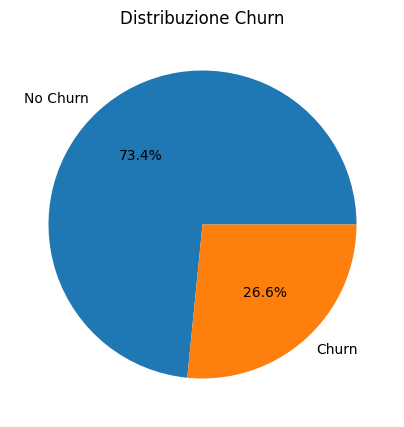

In [192]:
churn_counts = churn_ds['Churn'].value_counts()
churn_counts.index = ['No Churn', 'Churn']

churn_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5, 5),
    title='Distribuzione Churn'
)
plt.ylabel('')
plt.show()

Il dataset presente un evidente sbilanciamento della feature da predire: la maggior parte dei clienti non ha abbandonato il servizio.

Osserviamo la distribuzione dei mesi di permanenza:

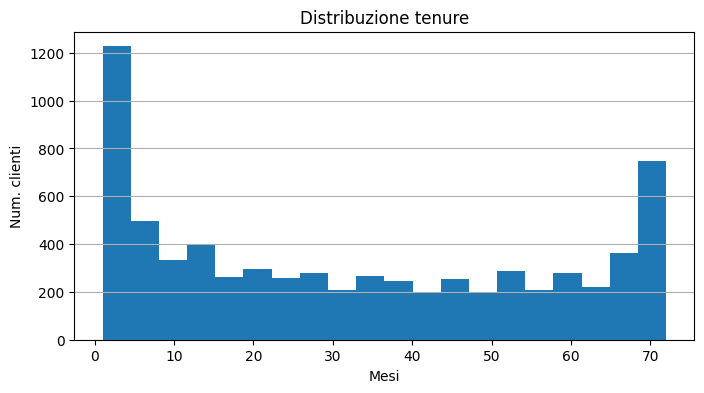

In [193]:
def plot_hist(feature, xlabel, ylabel):
  churn_ds[feature].plot.hist(bins=20, figsize=(8, 4))
  plt.title(f"Distribuzione {feature}")
  plt.grid(axis="y")

  plt.xlabel(xlabel)
  plt.ylabel(ylabel)
  plt.show()

plot_hist("tenure", "Mesi", "Num. clienti")

Sono evidenti due picchi marcati agli estremi, con parte centrale relativamente piatta. Questo suggerisce che che esiste una larga quota di clienti nuovi e quota significativa di clienti fidelizzati di lunga data.

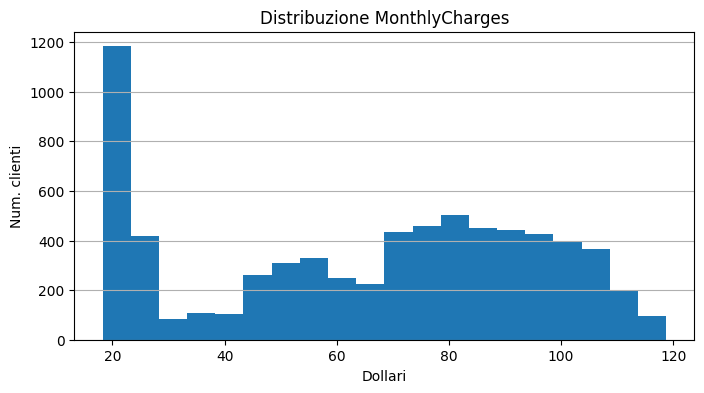

In [194]:
plot_hist('MonthlyCharges', 'Dollari', "Num. clienti")

La distribuzione è molto pronunciata verso la fascia più bassa, che corrisponde probabilmente ai clienti con solo servizio telefonico base/senza servizio internet, i quali quindi hanno una spesa mensile minore.

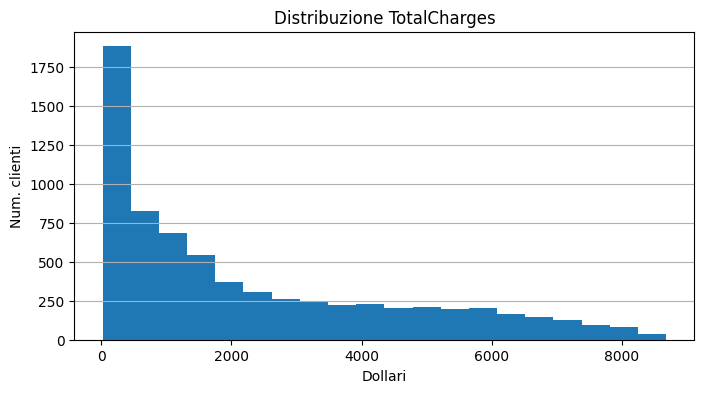

In [195]:
plot_hist('TotalCharges', 'Dollari', "Num. clienti")

La maggior parte dei clienti si concentra in una spesa complessiva di 2000 dollari: da lì in poi il grafico descresce molto velocemente. Questo indica che la maggior parte dei clienti ha una spesa totale bassa, probabilmente dato dalle due feature precedeti: molti clienti sono nuovi e la maggior parte di essi ha una spesa mensile contenuta.

Confrontiamo ora le variabili numeriche con l'abbandono dei clienti:

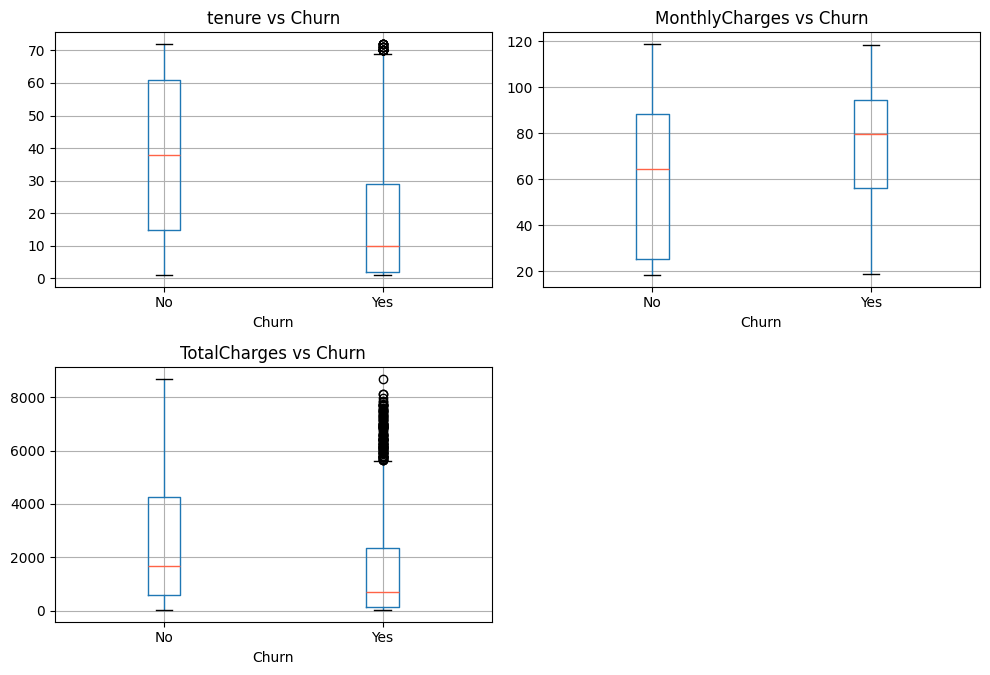

In [196]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    churn_ds.boxplot(column=col, by='Churn', ax=axes[i], medianprops=dict(color='tomato'))
    axes[i].set_title(f'{col} vs Churn')

axes[3].set_visible(False)
plt.suptitle('')
plt.tight_layout()
plt.show()

- `tenure`: i clienti che abbandonano hanno una mediana di solo 10 mesi, contro i circa 40 dei clienti fidelizzati. Il 75% dei clienti che abbandonano ha meno di 30 mesi di anzianità. Questo suggerisce che tenure possa essere una delle variabili più significative per la predizione del churn: clienti che hanno una anzianità più bassa sono più propensi ad abbandonare l'azienda.
- `MonthlyCharges`: i clienti che abbandonano spendono in media 74\$ al mese, contro i 61\$ dei clienti fedeli. Questo suggerisce che clienti con piani più costosi (probilemente dovuto all'attivazione di servizi multipli) siano più propensi ad abbandonare.
- `TotalCharges`: come già detto, la distribuzione è largamente influenzata da `tenure`, infatti i clienti che abbandonano hanno una spesa mediana di 700\$ circa, contro i 1600\$ circa dei fidelizzati. Chi abbandona presto accumula naturalmente meno spesa totale. Risulta quindi una variabile parzialmente ridondante da mantenere. E' inoltre possibile notare come ci siano molti outliner tra chi abbandona: una minoranza di clienti abbandona dopo molti anni di permanenza.

Visualizziamo ora un confronto tra le variabili categoriche che reputo più significative e l'abbandono dei clienti. Per farlo, mappiamo gli `Yes` e `No` di Churn rispettivamente in `1` e `0`.

In [197]:
# mappatura per la rappresentazione dei valori
churn_ds['Churn'] = np.where(churn_ds['Churn'] == "Yes", 1, 0)

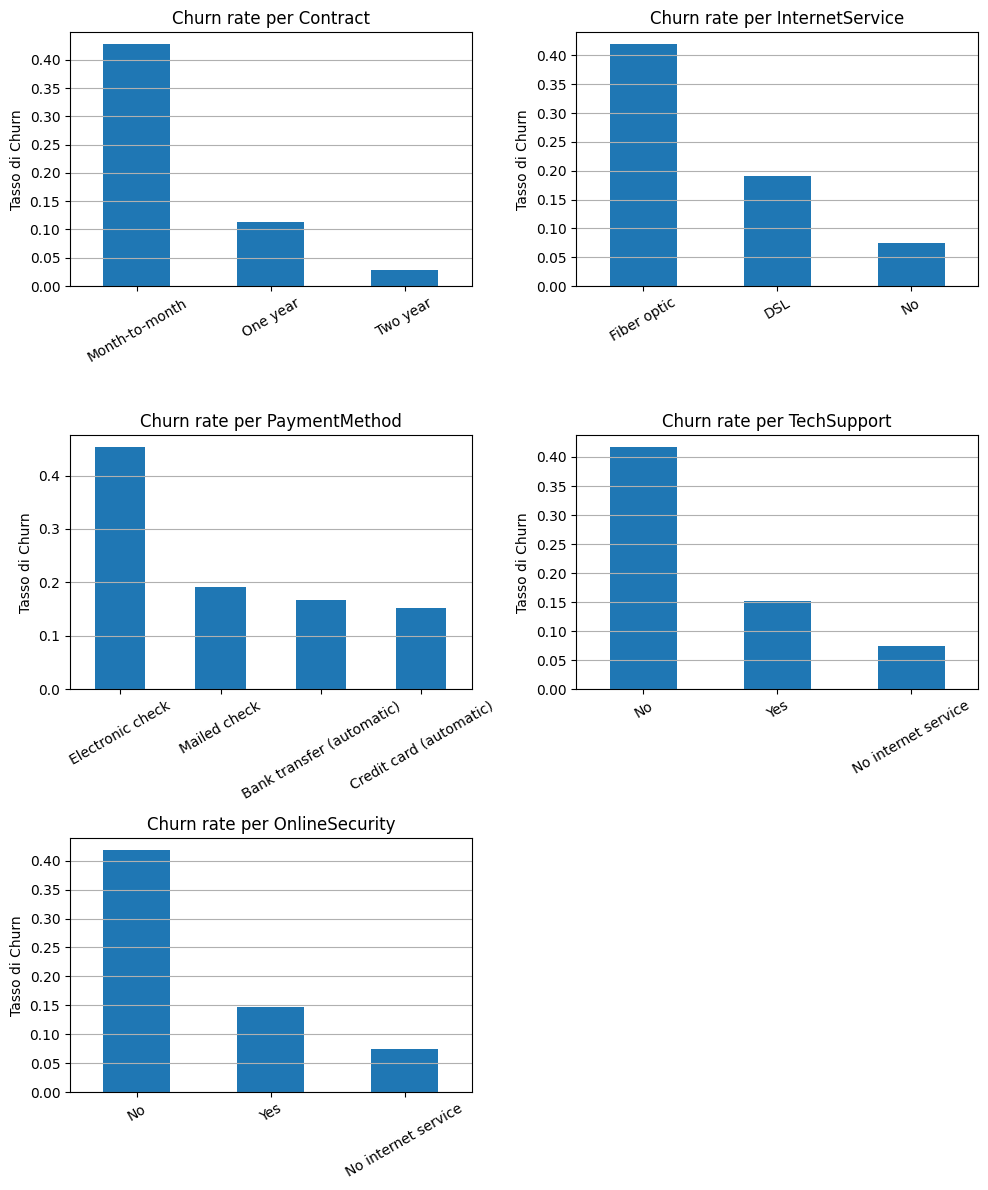

In [198]:
cat_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'TechSupport', 'OnlineSecurity']

fig, axes = plt.subplots(3, 2, figsize=(10, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    churn_rate = churn_ds.groupby(col)['Churn'].mean().sort_values(ascending=False)
    churn_rate.plot.bar(ax=axes[i])
    axes[i].set_title(f'Churn rate per {col}')
    axes[i].set_ylabel('Tasso di Churn')
    axes[i].set_xlabel('')
    axes[i].grid(axis='y')
    axes[i].tick_params(axis='x', rotation=30)

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

- `Contract`: è una delle feature con il segnale maggiore per l'abbandono, come precedentemente ipotizzato: i clienti con contratto Month to month hanno un tasso di churn maggiore del 40%, dovuto alla flessibilità del contratto
- `InternetService`: i clienti Fiber optic hanno un abbandono maggiore del 40%, più del doppio rispetto a DSL. Presumibilmente l'abbandono maggiore è legato al costo più alto di un piano in fibra.
- `PaymentMethod`: il metodo Electronic check ha il tasso di churn più alto (45% circa)
- `TechSupport`: i clienti senza supporto tecnico hanno un tasso di abbandono maggiore del 40%. Una maggiore insoddisfazione nel servizio porta ovviamente ad abbandono più alto.
- `OnlineSecurity`: visivamente molto simile a `TechSupport`. I servizi aggiuntivi di sicurezza sembrano aumentare significativamente la fidelizzazione.

Per le feature numeriche, visualizziamo la correlazione di Pearson. La seguente è una heat map che mostra tutte le correlazioni tra le variabili numeriche:

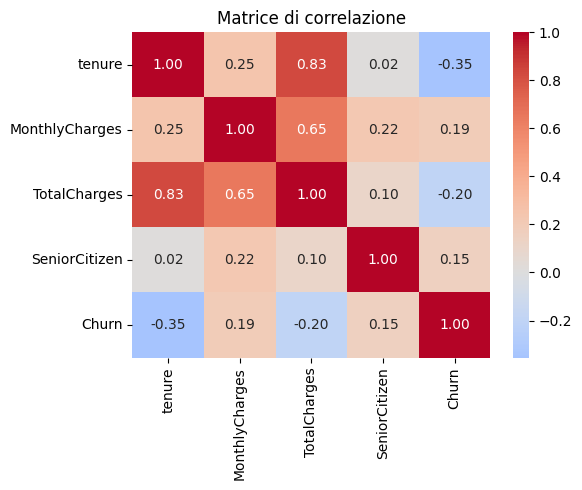

In [199]:
corr = churn_ds[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn']].corr()

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111)

sb.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)

plt.title('Matrice di correlazione')
plt.tight_layout()
plt.show()

E' possibile notare che `tenure` abbia la correlazione più forte con la variabile dipendente: più a lungo un cliente rimane, meno è probabile che abbandoni.

Un'altra correlazione molto alta (0.85), come ci si poteva aspettare, è data da `tenure` e `TotalCharges`. Come già discusso in precedenza, la presenza di entrambe può risultare ridondante.

## Preprocessing

Si sceglie di rimuovere `TotalCharges` perchè largamente influenzata da `tenure`, con una correlazione molto alta. Il motivo è semplice:
<br/><br/>
$$
\text{TotalCharges} \approx \text{tenute} \times \text{MonthlyCharges}
$$
<br/>
quindi è quasi combinazione lineare di queste, come dimostra questo grafico:

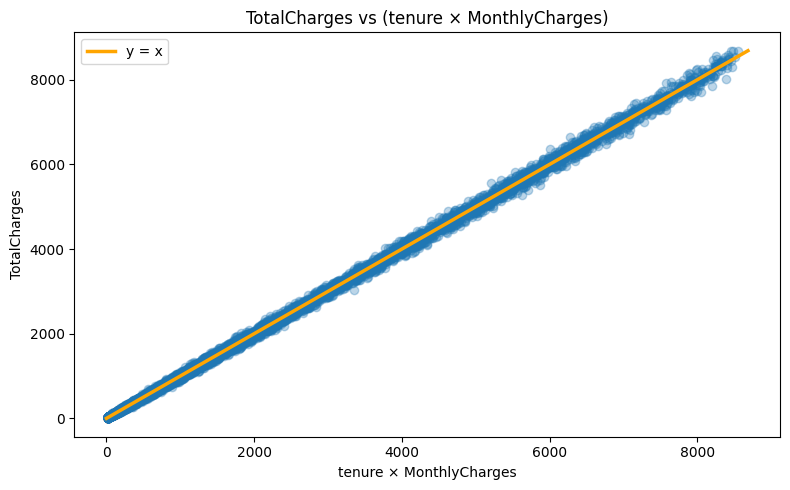

In [200]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    churn_ds['tenure'] * churn_ds['MonthlyCharges'],
    churn_ds['TotalCharges'],
    alpha=0.3,
)
ax.set_xlabel('tenure × MonthlyCharges')
ax.set_ylabel('TotalCharges')
ax.set_title('TotalCharges vs (tenure × MonthlyCharges)')

lim = max(churn_ds['TotalCharges'].max(),
          (churn_ds['tenure'] * churn_ds['MonthlyCharges']).max())
ax.plot([0, lim], [0, lim], color='orange', linewidth=2.5, label='y = x')
ax.legend()

plt.tight_layout()
plt.show()

Si sceglie quindi di rimuoverla per ridondanza e pulizia del modello (più semplice da interpretare)

In [201]:
churn_ds = churn_ds.drop(columns=['TotalCharges'])

### Encoding

Molte feature sono binarie e prevedono come valori `Yes`/`No`. Le trasformo in 0/1:

In [202]:
# Churn è già stata mappata precedentemente
binary_cols = ['Partner', 'Dependents', 'PaperlessBilling', 'PhoneService']

for col in binary_cols:
    churn_ds[col] = np.where(churn_ds[col] == 'Yes', 1, 0)

churn_ds[binary_cols].head()

,Partner,Dependents,PaperlessBilling,PhoneService
0,1,0,1,0
1,0,0,0,1
2,0,0,1,1
3,0,0,0,0
4,0,0,1,1


Effettuiamo la stessa trasformazione per la feature `gender`, rinominandola in `GenderMale` che mappa a 1 i clienti `Male` e 0 per `Female`

In [203]:
churn_ds['GenderMale'] = np.where(churn_ds['gender'] == 'Male', 1, 0)
churn_ds = churn_ds.drop(columns=['gender'])

churn_ds['GenderMale'].head()

,GenderMale
0,0
1,1
2,1
3,1
4,0


Molte feature categoriche presentano più di due classi possibili (ad esempio `Contract` che può assumere come valori Month-to-month, One year, Two year). Applichiamo `OneHotEncoder` per trasformare ogni possibile valore in una feature

In [204]:
# colonne con 3+ categorie
enc_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

# rimuviamo una categoria per evitare ridondanze
encoder = OneHotEncoder(drop="first", sparse_output=False, dtype=int)

enc_array = encoder.fit_transform(churn_ds[enc_cols])

# costruisco un dataframe con i nomi delle colonne generate dall'encoder
enc_df = pd.DataFrame(
    enc_array,
    columns=encoder.get_feature_names_out(enc_cols),
    index=churn_ds.index
)

# rimuovo le colonne originali, rimpiazzandole con quelle binarie
churn_ds = pd.concat([churn_ds.drop(columns=enc_cols), enc_df], axis=1)

churn_ds.head()


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,Churn,GenderMale,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,0,1,0,1,29.85,0,0,1,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,34,1,0,56.95,0,1,0,...,0,0,0,0,0,1,0,0,0,1
2,0,0,0,2,1,1,53.85,1,1,0,...,0,0,0,0,0,0,0,0,0,1
3,0,0,0,45,0,0,42.30,0,1,1,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,2,1,1,70.70,1,0,0,...,0,0,0,0,0,0,0,0,1,0


In questo modo possiamo vedere che tutte le feature sono diventate numeriche, in modo che possano essere utilizzate dei modelli che addestreremo.

In [205]:
churn_ds.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   Partner                                7032 non-null   int64  
 2   Dependents                             7032 non-null   int64  
 3   tenure                                 7032 non-null   int64  
 4   PhoneService                           7032 non-null   int64  
 5   PaperlessBilling                       7032 non-null   int64  
 6   MonthlyCharges                         7032 non-null   float64
 7   Churn                                  7032 non-null   int64  
 8   GenderMale                             7032 non-null   int64  
 9   MultipleLines_No phone service         7032 non-null   int64  
 10  MultipleLines_Yes                      7032 non-null   int64  
 11  InternetS

Il numero di feature è salito a 30:

In [206]:
churn_ds.shape

(7032, 30)

Separiamo le variabili indipendenti da quella dipendente (`Churn`)

In [207]:
churn_X = churn_ds.drop(columns=['Churn'])
churn_y = churn_ds['Churn']

Divido il dataset in train e test set. Specifico `stratify=churn_y` in modo che il bilanciamento delle classi venga rispettato sia nel set di training che in quello di test. Utilizziamo 1/3 dei dati per la validazione.

In [208]:
churn_X_train, churn_X_test, churn_y_train, churn_y_test = train_test_split(
    churn_X, churn_y,
    test_size=1/3,
    random_state=42,
    stratify=churn_y
)

## Modellazione

Prima di procedere con l'addestramento dei modelli, chiariamo alcune scelte comuni a tutta la fase di modellazione

### Pipeline: StandardScaler e SMOTE

Per ciascun modello costruisco una Pipeline che includa tre step: `StandardScaler`, `SMOTE` e il classificatore.

- Utilizzo uno `StandardScaler` per normalizzare le feature numeriche: questo è necessario per la Logistic Regression, i cui coefficienti sono sensibili alla scala delle feature. Senza scaling, feature con valori numericamente grandi come `MonthlyCharges` dominerebbero artificialmente rispetto a variabili binarie. Per Decision Tree, Random Forest e XGBoost lo scaling è irrilevante poichè sono modelli ad albero.

- `SMOTE` viene integrato direttamente nella pipeline invece di essere applicato una volta sola prima dello split. Questa scelta è dovuta all'uso della cross validation per valutare in modo migliore il modello: includendolo nella pipeline, per ogni fold della cross validation SMOTE viene applicato esclusivamente sui dati di training del fold, mai su quelli della validazione, garantendo una valutazione più rappresentativa delle performance reali.

### Metrica di riferimento

Con classi sbilanciate, l'accuracy può essere fuorviante: un modello che predice No Churn otterrebbe già il 73% di accuracy, senza utilità. La metrica che penso sia prioritaria, e che quindi prenderò come riferimento per valutare il modello migliore, è la **recall**, ovvero la capacità del modello di intercettare i clienti realmente a rischio di abbandono: in questo problema identificare un falso negativo (un cliente che abbandona classificato come fidelizzato) è più importante che trovare falsi positivi (clienti fedeli classificati a rischio abbandono).

### Utility

Definisco qui di seguito tutte le funzioni e variabili di utility che userò:

In [209]:
# metriche utilizzate
scoring = ['accuracy', 'precision', 'recall', 'f1']

# dizionario di appoggio per salvare gli score dei vari modelli
results = {}

In [210]:
# costruisce una pipeline scaler + smote + modello scelto
def pipe_with_model(model):
    return Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('model', model)
    ])

# applica una cross validation 5-fold sulla
# pipe passata come argomento e stampa le metriche
# risultanti
def cross_validate_scores(pipe, X_train, y_train):
  cv = cross_validate(pipe, X_train, y_train, cv=5, scoring=scoring)
  for metric in scoring:
    print(f"{metric}: {cv[f'test_{metric}'].mean():.3f}")

# stampa le metriche in base ai valori di test effettivi
# e quelli predetti. Salva le metriche in results.
def test_scores(y_test, y_pred, modelName):
  results[modelName] = {
      'accuracy': accuracy_score(y_test, y_pred),
      'precision': precision_score(y_test, y_pred),
      'recall': recall_score(y_test, y_pred),
      'f1': f1_score(y_test, y_pred)
  }
  for metric, value in results[modelName].items():
    print(f"{metric}: {value:.3f}")

# costruisce la confusion matrix data dai valori
# target effettivi e quelli predetti e la ritorna come frame
def confusion_matrix_df(y_test, y_pred):
  cm = confusion_matrix(y_test, y_pred)
  cm_df = pd.DataFrame(
      cm,
      index=['No Churn effettivo', 'Churn effettivo'],
      columns=['Predetto No Churn', 'Predetto Churn']
  )
  return cm_df

### Logistic Regression

La regressione logistica è il primo modello che addestriamo. Grazie alla sua linearità potremo confrontare i coefficienti associati a ciascuna feature, per quantificare direttamente il contributo di ciascuna di esse alla predizione del churn.

In [211]:
pipe_lr = pipe_with_model(
    LogisticRegression(random_state=42, max_iter=1000)
)

# cross validation
cross_validate_scores(pipe_lr, churn_X_train, churn_y_train)

accuracy: 0.757
precision: 0.530
recall: 0.778
f1: 0.630


Effettuiamo l'addestramento del modello e valutiamo con le medesime metriche anche sul test set

In [212]:
pipe_lr.fit(churn_X_train, churn_y_train)
y_pred_lr = pipe_lr.predict(churn_X_test)

test_scores(churn_y_test, y_pred_lr, "LogisticRegression")

accuracy: 0.748
precision: 0.517
recall: 0.785
f1: 0.623


La regressione logistica ottiene una accuracy del 74.8% sul test set con un recall del 78.5%. Il modello intercetta circa 8 clienti a rischio su 10.

Le metriche di cross validation e test set sono molto allineate (F1: 0.630 vs 0.623), confermando che integrare SMOTE nella Pipeline produce una valutazione stabile.

La precision del 51.7% indica che circa metà degli allarmi sono falsi positivi.

Possiamo notare che le classi del modello sono, in ordine, `[No Churn, Churn]`. Questo è dato dal fatto che sono mappate rispettivamente come 0/1 e sklearn ordina le classi automaticamente in modo crescente:

In [213]:
np.where(pipe_lr.classes_, "Churn", "No Churn")

array(['No Churn', 'Churn'], dtype='<U8')

Visualizziamo ora la matrice di confusione:

In [214]:
print("Confusion Matrix: LogisticRegression")
confusion_matrix_df(churn_y_test, y_pred_lr)

Confusion Matrix: LogisticRegression


,Predetto No Churn,Predetto Churn
No Churn effettivo,1264,457
Churn effettivo,134,489


La matrice di confusione conferma le metriche recall e precision: c'è un trade-off accettabile per il problema. Il modello "preferisce" sbagliare in eccesso sui clienti che non lasceranno l'azienda ma che vengono classificati come tali, piuttosto che sui clienti che effettivamente abbandonano ma che non vengono rilevati.

Estraiamo ed analizziamo i coefficienti del modello per verificare se le osservazioni effettuate durante la fase di esplorazione siano corrette.
Le 5 feature più rilevanti per la predizione sono:




In [215]:
coefs_lr = pipe_lr.named_steps['model'].coef_[0]

coef_df_lr = pd.DataFrame({
    'Feature': churn_X_train.columns,
    'Coefficiente': coefs_lr,
    'Importanza (|coef|)': np.abs(coefs_lr)
}).sort_values('Importanza (|coef|)', ascending=False).reset_index(drop=True)

coef_df_lr.head()

,Feature,Coefficiente,Importanza (|coef|)
0,tenure,-0.838064,0.838064
1,InternetService_Fiber optic,0.773058,0.773058
2,MonthlyCharges,-0.682230,0.682230
3,Contract_Two year,-0.667108,0.667108
4,StreamingMovies_Yes,0.301016,0.301016


- `tenure` è la feature più importante in assoluto. Il suo coefficiente negativo conferma che più a lungo un cliente rimane, minore è la probabilità che abbandoni.
- `InternetService_Fiber optic` conferma un'altra ipotesi: contratti di clienti che includono la fibra ottica aumentano significativamente il rischio di abbandono
- `MonthlyCharges` ha una alta rilevanza nel classificare il churn ed ha segno negativo, controinuitivo rispetto alla fase di esplorazione dei dati, dove i clienti che abbadnonano spendevano di più
- `Contract_Two year` conferma che i contratti lunghi fidelizzano i clienti

In [216]:
coef_df_lr.tail()

,Feature,Coefficiente,Importanza (|coef|)
24,PaymentMethod_Credit card (automatic),0.019053,0.019053
25,GenderMale,0.011267,0.011267
26,Partner,0.009677,0.009677
27,PhoneService,-0.006065,0.006065
28,MultipleLines_No phone service,0.006065,0.006065


Queste ultime feature hanno coefficienti quasi nulli (<0.02).
Il sesso del cliente o il suo stato relazionale non influenzano in modo significativo la probabilità che esso abbandoni. `PhoneService` risulta la seconda meno rilevante, probabilmente dato dal fatto che quasi tutti i clienti possiedono il servizio telefonico.

### Decision Tree

Come secondo modello utilizziamo il Decision Tree, un classificatore ad albero. A differenza della regressione logistica, il Decision Tree non assume una relazione lineare tra le feature e il target, ma partiziona lo spazio delle feature in regioni tramite split successivi

In [217]:
pipe_dt = pipe_with_model(
    DecisionTreeClassifier(random_state=42)
)

# cross validation
cross_validate_scores(pipe_dt, churn_X_train, churn_y_train)

accuracy: 0.732
precision: 0.496
recall: 0.588
f1: 0.538


Come prima, addestriamo il modello e valutiamo le metriche

In [218]:
pipe_dt.fit(churn_X_train, churn_y_train)
y_pred_dt = pipe_dt.predict(churn_X_test)

test_scores(churn_y_test, y_pred_dt, "DecisionTreeClassifier")

accuracy: 0.724
precision: 0.484
recall: 0.568
f1: 0.523


Il gap tra cross validation e test set è contenuto, indicando una buona capacità di generalizzazione.

La matrice di confusione risultante è la seguente.

In [219]:
print("Confusion Matrix: DecisionTreeClassifier")
confusion_matrix_df(churn_y_test, y_pred_dt)

Confusion Matrix: DecisionTreeClassifier


,Predetto No Churn,Predetto Churn
No Churn effettivo,1343,378
Churn effettivo,269,354


Il Decision Tree è peggiore della Logistic Regression su tutte le metriche, in particolare sul recall (0.568 vs 0.785). Vengono identificati male 269 clienti a rischio churn rispetto ai 134 della regressione logistica.

Visualizziamo quali decisioni risultano tra le più importanti per classificare un cliente secondo l'albero.

In [220]:
print(
    export_text(
      pipe_dt.named_steps['model'],
      feature_names=list(churn_X_train.columns),
      max_depth=2
    )
)

|--- Contract_Two year <= 1.73
|   |--- Contract_One year <= 1.96
|   |   |--- InternetService_Fiber optic <= -0.89
|   |   |   |--- truncated branch of depth 23
|   |   |--- InternetService_Fiber optic >  -0.89
|   |   |   |--- truncated branch of depth 21
|   |--- Contract_One year >  1.96
|   |   |--- StreamingMovies_Yes <= -0.78
|   |   |   |--- truncated branch of depth 11
|   |   |--- StreamingMovies_Yes >  -0.78
|   |   |   |--- truncated branch of depth 16
|--- Contract_Two year >  1.73
|   |--- MonthlyCharges <= 1.23
|   |   |--- MonthlyCharges <= 0.95
|   |   |   |--- truncated branch of depth 14
|   |   |--- MonthlyCharges >  0.95
|   |   |   |--- truncated branch of depth 9
|   |--- MonthlyCharges >  1.23
|   |   |--- tenure <= 1.61
|   |   |   |--- truncated branch of depth 10
|   |   |--- tenure >  1.61
|   |   |   |--- truncated branch of depth 2



Questo modello da più importanza al tipo di contratto stipulato rispetto che all'anzianità del cliente: la feature radice è la stipulazione di un contratto biennale, seguita da quello annuale e dalla spesa mensile. Già dalla fase di esplorazione dei dati è emerso che contratti più lunghi fidelizzano il cliente. Il seguente grafico rende la suddivisione più chiara:

> Nota: i valori delle soglie sono in scala standardizzata, non corrispondono quindi ai valori originali.

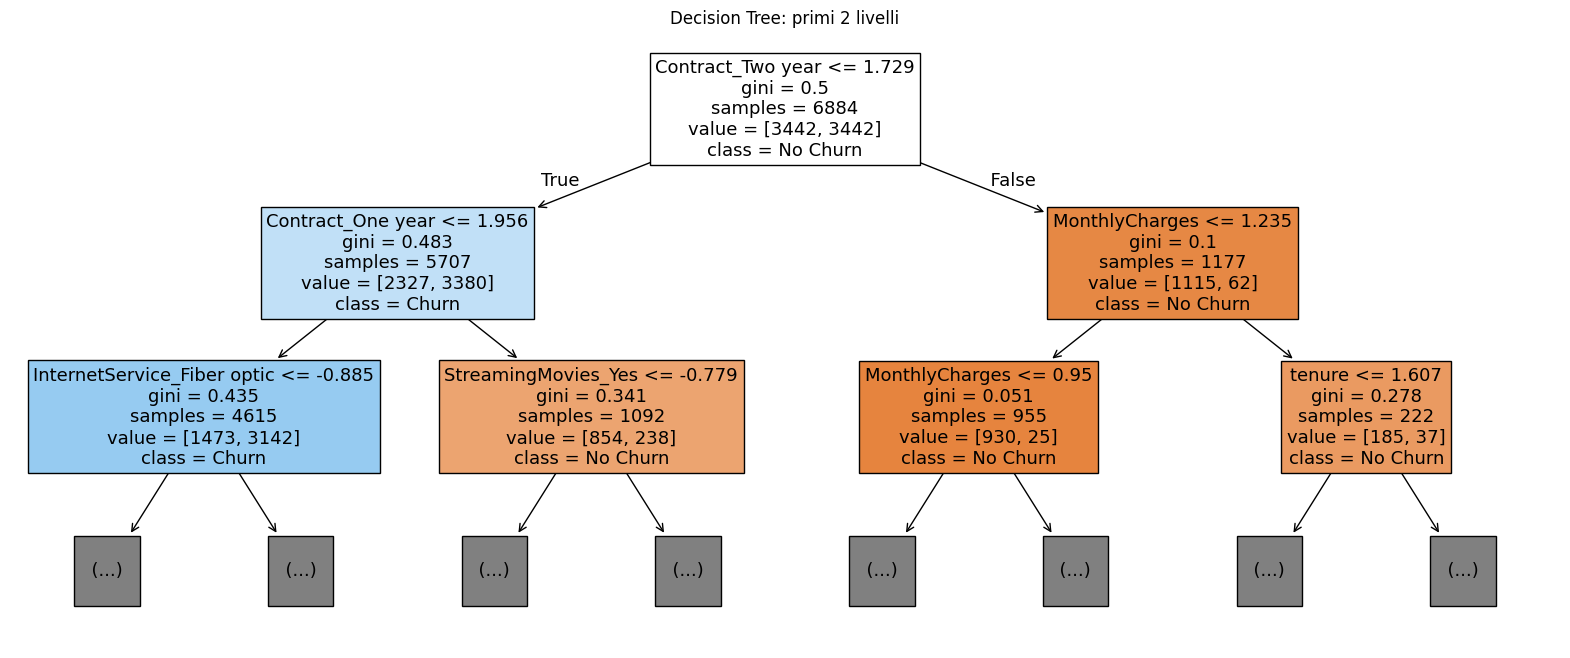

In [221]:
plt.figure(figsize=(20, 8))
plot_tree(
    pipe_dt.named_steps['model'],
    feature_names=churn_X_train.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    max_depth=2,
    fontsize=13,
)
plt.title('Decision Tree: primi 2 livelli')
plt.show()

### Random Forest

Poichè Decision Tree non ha dato risultati soddisfacendi rispetto alla regressione logistica, addestriamo anche un modello Random Forest (più Decision Tree addestrati in parallelo). Addestrando ogni albero su un sottoinsieme casuale delle feature si tenta di migliorare le metriche

In [222]:
pipe_rf = pipe_with_model(
    RandomForestClassifier(random_state=42)
)

# cross validation
cross_validate_scores(pipe_rf, churn_X_train, churn_y_train)

accuracy: 0.781
precision: 0.594
recall: 0.555
f1: 0.573


In [223]:
pipe_rf.fit(churn_X_train, churn_y_train)
y_pred_rf = pipe_rf.predict(churn_X_test)

test_scores(churn_y_test, y_pred_rf, "RandomForestClassifier")

accuracy: 0.776
precision: 0.580
recall: 0.567
f1: 0.573


In [224]:
print("Confusion Matrix: RandomForestClassifier")
confusion_matrix_df(churn_y_test, y_pred_rf)

Confusion Matrix: RandomForestClassifier


,Predetto No Churn,Predetto Churn
No Churn effettivo,1465,256
Churn effettivo,270,353


Il random forest migliora il decision tree su tutte le metriche. Tuttavia, la logistic regression rimane superiore sul recall (0.785 vs 0.567): il modello manca 270 clienti a rischio contro i 134 della logistic regression.

In [225]:
imp_rf = pd.DataFrame({
    'Feature': churn_X_train.columns,
    'Importanza': pipe_rf.named_steps['model'].feature_importances_
}).sort_values('Importanza', ascending=False).reset_index(drop=True)

imp_rf.head()

,Feature,Importanza
0,tenure,0.203147
1,MonthlyCharges,0.164391
2,Contract_Two year,0.069663
3,InternetService_Fiber optic,0.054241
4,PaymentMethod_Electronic check,0.045930


Il random forest associa una importanza maggiore all'anzianità del cliente, alla sua spesa mensile e ai contratti biennali. Questi pesi sono coerenti con quelli riscontrati nella regressione logistica.

### XGBoost

A differenza del random forest che costruisce alberi in parallelo, XGBoost li costruisce in sequenza: ogni albero corregge gli errori del precedente. Proviamo ad applicare questo modello alla classificazione del churn.

In [226]:
pipe_xgb = pipe_with_model(
    XGBClassifier(random_state=42)
)

# cross validation
cross_validate_scores(pipe_xgb, churn_X_train, churn_y_train)

accuracy: 0.776
precision: 0.582
recall: 0.566
f1: 0.573


In [227]:
pipe_xgb.fit(churn_X_train, churn_y_train)
y_pred_xgb = pipe_xgb.predict(churn_X_test)

test_scores(churn_y_test, y_pred_xgb, "XGBClassifier")

accuracy: 0.781
precision: 0.590
recall: 0.576
f1: 0.583


XGBoost ottiene l'accuracy più alta tra tutti i modelli (78.1%) e la precision più alta. Il basso gap tra test set e cross validation conferma una buona capacità di generalizzazione. In modo analogo al random forest, il recall rimane inferiore a quello della Logistic Regression, classificando male 264 clienti a rischio contro i 134 della LR.

In [228]:
print("Confusion Matrix: XGBClassifier")
confusion_matrix_df(churn_y_test, y_pred_xgb)

Confusion Matrix: XGBClassifier


,Predetto No Churn,Predetto Churn
No Churn effettivo,1472,249
Churn effettivo,264,359


In [229]:
imp_xgb = pd.DataFrame({
    'Feature': churn_X_train.columns,
    'Importanza': pipe_xgb.named_steps['model'].feature_importances_
}).sort_values('Importanza', ascending=False).reset_index(drop=True)

imp_xgb.head()

,Feature,Importanza
0,Contract_Two year,0.365970
1,InternetService_Fiber optic,0.137013
2,Contract_One year,0.115922
3,InternetService_No,0.074796
4,StreamingMovies_Yes,0.036365


Per quanto riguarda i pesi delle feature, il contratto biennale domina con una importanza tre volte superiore alla seconda feature, il servizio in fibra. A differenza di random forest, l'anzianità del cliente e la sua spesa mensile non compaiono tra le feature più importanti.

### Confronto generale

Di seguito sono presenti le metriche a confronto tra tutti i modelli. La Logistic Regression rimane il modello migliore per la recall, nonostante sia il più semplice dei quattro. RandomForest e XGBoost ottengono accuracy e precision più alte ma sacrificano la recall. L'ottimizzazione degli iperparametri potrebbe migliorare questo trade-off

In [230]:
results_ds = pd.DataFrame(results).T.round(3)
results_ds

,accuracy,precision,recall,f1
LogisticRegression,0.748,0.517,0.785,0.623
DecisionTreeClassifier,0.724,0.484,0.568,0.523
RandomForestClassifier,0.776,0.580,0.567,0.573
XGBClassifier,0.781,0.590,0.576,0.583


## Ottimizzazione degli iperparametri

Ottimizziamo gli iperparametri della Logistic Regression e di XGBoost, i due modelli con le performance più interessanti: la LR ha la recall più alta, XGBoost ha l'accuracy migliore.

In entrambi i casi la metrica che si cerca di ottimizzare è la recall, in modo da riuscire ad intercettare il maggior numero possibile di clienti a rischio abbandono.

### Logistic Regression: GridSearch

Per la logistic regression utilizziamo `GridSearchCV` con due griglie separate: la prima esplora la regolarizzazione `l1` e `l2`, la seconda esplora `elasticnet` che richiede il parametro aggiuntivo `l1_ratio`:

In [231]:
# griglie con le combinazioni di attributi
param_grid_lr = [
    {
        'model__penalty': ['l1', 'l2'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__solver': ['liblinear']
    },
    {
        'model__penalty': ['elasticnet'],
        'model__C': [0.01, 0.1, 1, 10],
        'model__l1_ratio': [0.2, 0.5, 0.8],
        'model__solver': ['saga']
    }
]

gs_lr = GridSearchCV(
    pipe_lr,
    param_grid_lr,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

gs_lr.fit(churn_X_train, churn_y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('smote', SMOTE(random_state=42)),
                                       ('model',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid=[{'model__C': [0.01, 0.1, 1, 10],
                          'model__penalty': ['l1', 'l2'],
                          'model__solver': ['liblinear']},
                         {'model__C': [0.01, 0.1, 1, 10],
                          'model__l1_ratio': [0.2, 0.5, 0.8],
                          'model__penalty': ['elasticnet'],
                          'model__solver': ['saga']}],
             scoring='recall')

La combinazione migliore di iperparametri trovata è la seguente:

In [232]:
gs_lr.best_params_

{'model__C': 0.01, 'model__penalty': 'l1', 'model__solver': 'liblinear'}

Nel dettaglio, queste sono le 5 migliori, ordinate per recall:

In [233]:
cv_results_lr = pd.DataFrame(gs_lr.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score')

cv_results_lr.columns = ['Parametri', 'Recall medio', 'Std', 'Rank']
cv_results_lr.round(3)
cv_results_lr.head()

,Parametri,Recall medio,Std,Rank
0,"{'model__C': 0.01, 'model__penalty': 'l1', 'mo...",0.802577,0.029928,1
1,"{'model__C': 0.01, 'model__penalty': 'l2', 'mo...",0.795357,0.041747,2
2,"{'model__C': 0.1, 'model__penalty': 'l1', 'mod...",0.782512,0.042410,3
8,"{'model__C': 0.01, 'model__l1_ratio': 0.2, 'mo...",0.780903,0.041991,4
3,"{'model__C': 0.1, 'model__penalty': 'l2', 'mod...",0.779293,0.044722,5


### XGBoost: RandomSearch

Per XGBoost utilizzamo `RandomSearchCV`: il numero elevato di iperparametri renderebbe una ricerca esaustiva computazionalmente dispendiosa, quindi campioniamo casualmente un sottoinsieme di combinazioni.

In [234]:
param_grid_xgb = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 7],
    'model__learning_rate': [0.01, 0.1, 0.3],
    'model__subsample': [0.7, 0.8, 1.0]
}

rs_xgb = RandomizedSearchCV(
    pipe_xgb,
    param_grid_xgb,
    n_iter=20,
    cv=5,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)

rs_xgb.fit(churn_X_train, churn_y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                             ('smote', SMOTE(random_state=42)),
                                             ('model',
                                              XGBClassifier(base_score=None,
                                                            booster=None,
                                                            callbacks=None,
                                                            colsample_bylevel=None,
                                                            colsample_bynode=None,
                                                            colsample_bytree=None,
                                                            device=None,
                                                            early_stopping_rounds=None,
                                                            enable_categorical=False,
                                                            eval_metric=None,
                                                            feature_types=None,
                                                            featu...
                                                            min_child_weight=None,
                                                            missing=nan,
                                                            monotone_constraints=None,
                                                            multi_strategy=None,
                                                            n_estimators=None,
                                                            n_jobs=None,
                                                            num_parallel_tree=None, ...))]),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.1,
                                                                 0.3],
                                        'model__max_depth': [3, 5, 7],
                                        'model__n_estimators': [100, 200, 300],
                                        'model__subsample': [0.7, 0.8, 1.0]},
                   random_state=42, scoring='recall')

La combinazione migliore di iperparametri trovata è la seguente:

In [235]:
rs_xgb.best_params_

{'model__subsample': 0.7,
 'model__n_estimators': 100,
 'model__max_depth': 3,
 'model__learning_rate': 0.01}

Nel dettaglio, queste sono le 5 migliori, ordinate per recall:

In [236]:
cv_results_xgb = pd.DataFrame(rs_xgb.cv_results_)[
    ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
].sort_values('rank_test_score').reset_index(drop=True)

cv_results_xgb.columns = ['Parametri', 'Recall medio', 'Std', 'Rank']
cv_results_xgb.head(5)

,Parametri,Recall medio,Std,Rank
0,"{'model__subsample': 0.7, 'model__n_estimators...",0.813799,0.032909,1
1,"{'model__subsample': 0.8, 'model__n_estimators...",0.803377,0.037555,2
2,"{'model__subsample': 0.8, 'model__n_estimators...",0.775267,0.053872,3
3,"{'model__subsample': 0.7, 'model__n_estimators...",0.756003,0.041620,4
4,"{'model__subsample': 0.7, 'model__n_estimators...",0.742358,0.049751,5


## Conclusione

Valutiamo, con i migliori iperparametri trovati, anche sul test set sia per la regressione logistica che per XGBoost

In [237]:
# regressione logistica

y_pred_lr_opt = gs_lr.best_estimator_.predict(churn_X_test)
test_scores(churn_y_test, y_pred_lr_opt, 'Logistic Regression ottimizzata')
print()
confusion_matrix_df(churn_y_test, y_pred_lr_opt)

accuracy: 0.731
precision: 0.497
recall: 0.815
f1: 0.617



,Predetto No Churn,Predetto Churn
No Churn effettivo,1206,515
Churn effettivo,115,508


In [238]:
# xgboost

y_pred_xgb_opt = rs_xgb.best_estimator_.predict(churn_X_test)
test_scores(churn_y_test, y_pred_xgb_opt, 'XGBoost ottimizzata')
print()
confusion_matrix_df(churn_y_test, y_pred_xgb_opt)

accuracy: 0.729
precision: 0.494
recall: 0.827
f1: 0.618



,Predetto No Churn,Predetto Churn
No Churn effettivo,1193,528
Churn effettivo,108,515


L'ottimizzazione degli iperparametri ha prodotto risultati coerenti con l'obiettivo: massimizzare la recall a scapito di una leggera riduzione delle altre metriche:

In [239]:
metrics = ['accuracy', 'precision', 'recall', 'f1']
models = [
    ('LogisticRegression', 'Logistic Regression ottimizzata', 'Logistic Regression'),
    ('XGBClassifier', 'XGBoost ottimizzata', 'XGBoost')
]

rows = []
for base, optimized, name in models:
    for metric in metrics:
        before = results[base][metric]
        after = results[optimized][metric]
        rows.append((name, metric.capitalize(), before, after, after - before))

confronto = pd.DataFrame(
    rows,
    columns=['Modello', 'Metrica', 'Prima', 'Dopo', 'Delta']
)
confronto = confronto.round(3).set_index(['Modello', 'Metrica'])
confronto

Prima   Dopo  Delta
Modello             Metrica                       
Logistic Regression Accuracy   0.748  0.731 -0.017
                    Precision  0.517  0.497 -0.020
                    Recall     0.785  0.815  0.030
                    F1         0.623  0.617 -0.006
XGBoost             Accuracy   0.781  0.729 -0.052
                    Precision  0.590  0.494 -0.097
                    Recall     0.576  0.827  0.250
                    F1         0.583  0.618  0.035

Entrambi i modelli ottimizzati raggiungono performance simili sul test set (recall 0.815 vs 0.827, F1 0.617 vs 0.618). XGBoost presenta una recall più alta ma questa è statisticamente trascurabile. Per via del costo computazionale minore e della facile interpretabilità, LogisticRegression è il modello che si adatta meglio a questo problema, ottenendo anche risultati simili a XGBoost per recall e accuracy.

## Web app

Il modello di regressione logistica ottimizata è stato integrato in una web app tramite Flask, in modo che sia possibile inserire i dati di un cliente tramite form ed ottenere in tempo reale la predizione di churn con la relativa probabilità di abbandono.

Vengono esportati su disco alcuni file:
- `best_model.pkl`: pipeline completa del modello ottimizzato (StandardScaler + smote + regressione logistica), pronto ad effettuare predizioni
- `feature_names.pkl`: la lista ordinata delle feature dopo l'encoding, necessaria per garantire che il vettore di input costruito nella web app sia esattamente quello atteso dal modello
- `encoder.pkl`: l'encoder usato nel preprocessing che permette alla web app di ricevere i valori categorici originali e trasformarli correttamente

In [240]:
import pickle

if not os.path.exists("model"):
    os.mkdir("model")

# salviamo il best estimator della regressione logistica ottimizzata
with open("model/best_model.pkl", "wb") as f:
    pickle.dump(gs_lr.best_estimator_, f)

# salviamo i nomi delle feature dopo l'encoding
with open("model/feature_names.pkl", "wb") as f:
    pickle.dump(list(churn_X_train.columns), f)

# salviamo l'encoder utilizzato su questo modello
# (in questo modo possiamo usare le feature originali nella web app)
with open("model/encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

E' possibile utilizzare l'applicazione web visitando il seguente [link](https://customer-churn-classifier-theta.vercel.app/)